In [1]:
import numpy as np
import cv2

array([[[  7,   7,   7],
        [  1,   1,   1],
        [  1,   1,   1],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[  7,   7,   7],
        [  1,   1,   1],
        [  1,   1,   1],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[  7,   7,   7],
        [  1,   1,   1],
        [  1,   1,   1],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[  7,   7,   7],
        [  1,   1,   1],
        [  1,   1,   1],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[  7,   7,   7],
        [  1,   1,   1],
        [  1,   1,   1],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[  7,   7,   7],
        [  1,   1,   1],
        [  1,   1,   1],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
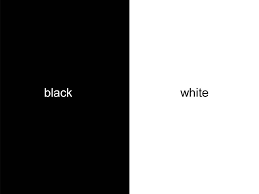

In [2]:
image_path = '/content/halfBW.png'

image = cv2.imread(image_path)
image

array([[  7,   1,   1, ..., 255, 255, 255],
       [  7,   1,   1, ..., 255, 255, 255],
       [  7,   1,   1, ..., 255, 255, 255],
       ...,
       [  7,   1,   1, ..., 255, 255, 255],
       [  7,   1,   1, ..., 255, 255, 255],
       [  7,   1,   1, ..., 255, 255, 255]], dtype=uint8)
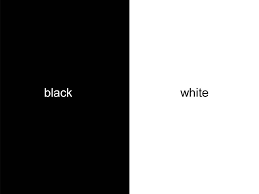

In [3]:
image_path = '/content/halfBW.png'

image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
image

In [4]:
sobel_vertical = np.array([[-1, 0, 1],
                           [-2, 0, 2],
                           [-1, 0, 1]])

sobel_vertical

array([[-1,  0,  1],
       [-2,  0,  2],
       [-1,  0,  1]])

In [5]:
image.shape

(194, 259)

In [8]:
rows, cols = image.shape
rows, cols

(194, 259)

In [9]:
k = sobel_vertical.shape[0]
k

3

In [10]:
output_matrix = np.zeros((rows - k + 1, cols - k + 1))
output_matrix

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [28]:
# Loop through the image excluding the border pixels
# (because a 3x3 kernel cannot be applied at the edges)
for i in range(1, rows - 1):
    for j in range(1, cols - 1):

        # Extract a 3x3 region (neighborhood) around the current pixel
        #i - 1  → row above the current pixel
        #i      → current row
        #i + 1  → row below the current pixel
        #Python slicing is end-exclusive, so:
        #i - 1 : i + 2

        region = image[i - 1 : i + 2, j - 1 : j + 2]

        # Apply the Sobel vertical kernel:
        # 1. Multiply the 3x3 region with the Sobel kernel (element-wise)
        # 2. Sum all the values to get the edge strength
        output_matrix[i - 1, j - 1] = np.sum(region * sobel_vertical)


In [15]:
output_matrix

array([[-24.,   0.,   0., ...,   0.,   0.,   0.],
       [-24.,   0.,   0., ...,   0.,   0.,   0.],
       [-24.,   0.,   0., ...,   0.,   0.,   0.],
       ...,
       [-24.,   0.,   0., ...,   0.,   0.,   0.],
       [-24.,   0.,   0., ...,   0.,   0.,   0.],
       [-24.,   0.,   0., ...,   0.,   0.,   0.]])

In [16]:
import matplotlib.pyplot as plt


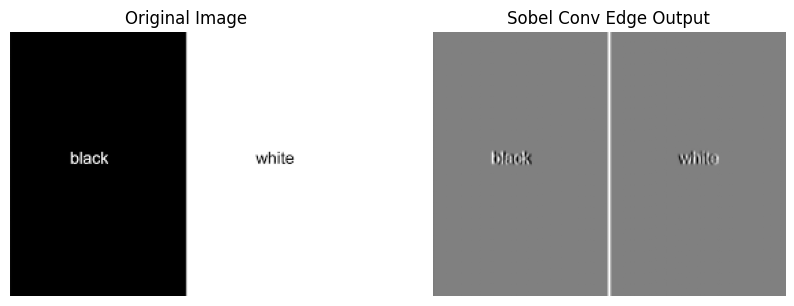

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

# Original Image
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(image, cmap='gray')
plt.axis('off')

# Sobel Output
plt.subplot(1, 2, 2)
plt.title("Sobel Conv Edge Output")
plt.imshow(output_matrix, cmap='gray')
plt.axis('off')

plt.show()


In [18]:
#cv2.filter2D(src, ddepth, kernel)
#src → input image
#ddepth = -1 → output has the same data type as the input image - > # uint8 (values from 0 to 255) so also use this for the outout image also
#kernel → convolution filter (here, sobel_vertical)

sobel_output = cv2.filter2D(image, -1, sobel_vertical)
sobel_output.shape

(194, 259)

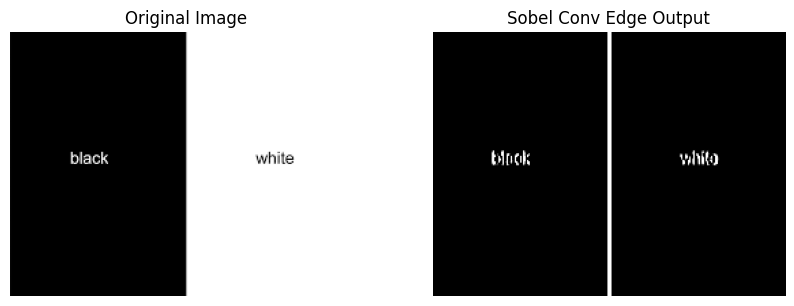

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

# Original Image
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(image, cmap='gray')
plt.axis('off')

# Sobel Output
plt.subplot(1, 2, 2)
plt.title("Sobel Conv Edge Output")
plt.imshow(sobel_output, cmap='gray')
plt.axis('off')

plt.show()


In [20]:
sobel_horizontal = np.array([[1, 2, 1],
                           [0, 0, 0],
                           [-1, -2, -1]])

sobel_horizontal

array([[ 1,  2,  1],
       [ 0,  0,  0],
       [-1, -2, -1]])

In [21]:
sobel_output = cv2.filter2D(image, -1, sobel_horizontal)
sobel_output.shape

(194, 259)

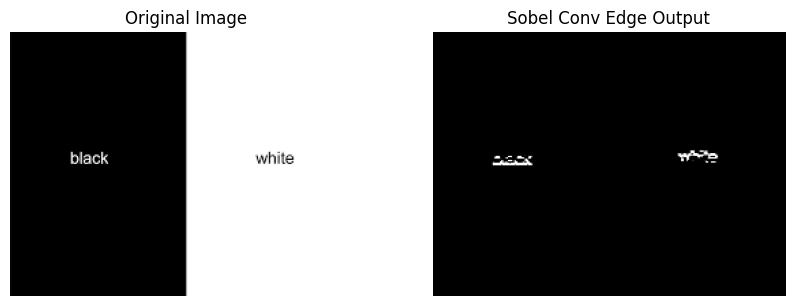

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

# Original Image
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(image, cmap='gray')
plt.axis('off')

# Sobel Output
plt.subplot(1, 2, 2)
plt.title("Sobel Conv Edge Output")
plt.imshow(sobel_output, cmap='gray')
plt.axis('off')

plt.show()


In [24]:
blur_image = np.array([[1, 1, 1],
                           [1, 1, 1],
                           [1, 1, 1]])/9

blur_image

array([[0.11111111, 0.11111111, 0.11111111],
       [0.11111111, 0.11111111, 0.11111111],
       [0.11111111, 0.11111111, 0.11111111]])

In [26]:
sobel_output = cv2.filter2D(image, -1, blur_image)
sobel_output.shape

(194, 259)

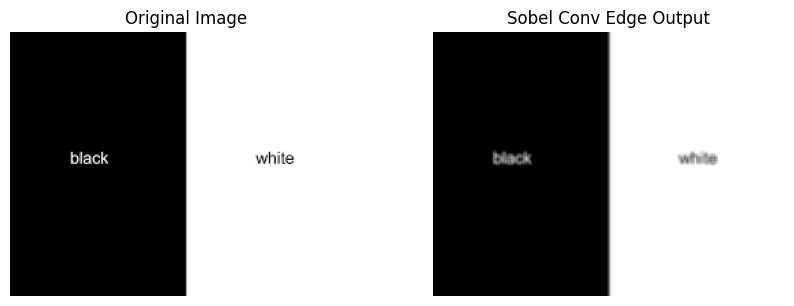

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

# Original Image
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(image, cmap='gray')
plt.axis('off')

# Sobel Output
plt.subplot(1, 2, 2)
plt.title("Sobel Conv Edge Output")
plt.imshow(sobel_output, cmap='gray')
plt.axis('off')

plt.show()
